## Load Data

In [1]:
import os
from pathlib import Path
from pnpl.datasets.libribrain2025 import constants_utils

constants_utils.set_remote_constants_url(
    f"{(Path(os.getcwd()) / 'constants.json').as_uri()}")
constants_utils.refresh_constants();

In [2]:
from pnpl.datasets.libribrain2025.constants import RUN_KEYS

RUN_KEYS += [("0", "2025", "COMPETITION_HOLDOUT", "1")]  # add holdout run

len(RUN_KEYS) # (subject, session, task, run)

91

In [3]:
RUN_KEYS

[('0', '1', 'Sherlock1', '1'),
 ('0', '2', 'Sherlock1', '1'),
 ('0', '3', 'Sherlock1', '1'),
 ('0', '4', 'Sherlock1', '1'),
 ('0', '5', 'Sherlock1', '1'),
 ('0', '6', 'Sherlock1', '1'),
 ('0', '7', 'Sherlock1', '1'),
 ('0', '8', 'Sherlock1', '1'),
 ('0', '9', 'Sherlock1', '1'),
 ('0', '10', 'Sherlock1', '1'),
 ('0', '11', 'Sherlock1', '2'),
 ('0', '12', 'Sherlock1', '2'),
 ('0', '1', 'Sherlock2', '1'),
 ('0', '2', 'Sherlock2', '1'),
 ('0', '3', 'Sherlock2', '1'),
 ('0', '4', 'Sherlock2', '1'),
 ('0', '5', 'Sherlock2', '1'),
 ('0', '6', 'Sherlock2', '1'),
 ('0', '7', 'Sherlock2', '1'),
 ('0', '8', 'Sherlock2', '1'),
 ('0', '9', 'Sherlock2', '1'),
 ('0', '10', 'Sherlock2', '1'),
 ('0', '11', 'Sherlock2', '1'),
 ('0', '12', 'Sherlock2', '1'),
 ('0', '1', 'Sherlock3', '1'),
 ('0', '2', 'Sherlock3', '1'),
 ('0', '3', 'Sherlock3', '1'),
 ('0', '4', 'Sherlock3', '1'),
 ('0', '5', 'Sherlock3', '1'),
 ('0', '6', 'Sherlock3', '1'),
 ('0', '7', 'Sherlock3', '1'),
 ('0', '8', 'Sherlock3', '1'),
 (

## Calculate Channel Stats

In [23]:
import h5py
from pnpl.datasets.libribrain2025.base import LibriBrainBase
from pnpl.datasets.libribrain2025.phoneme_dataset import LibriBrainPhoneme
import numpy as np
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = LibriBrainPhoneme(
    data_path='./data/',
    partition='train'
)
train_channel_means = torch.tensor(
    train_dataset.channel_means).to(device).unsqueeze(1)
train_channel_stds = torch.tensor(
    train_dataset.channel_stds).to(device).unsqueeze(1)


def compute_channel_stats(run_key):
    foo = LibriBrainBase(include_run_keys=[run_key], data_path='./data/')
    h5 = h5py.File(foo._ids_to_h5_path(*run_key), "r")["data"]
    data = h5[:]
    data = torch.tensor(data).to(device)
    channel_means_pre_std = torch.mean(data, axis=1)
    channel_stds_pre_std = torch.std(data, axis=1)
    std_data = (data - train_channel_means) / train_channel_stds
    channel_means = torch.mean(std_data, axis=1)
    channel_stds = torch.std(std_data, axis=1)
    return torch.cat([channel_means_pre_std, channel_stds_pre_std], axis=0).cpu(), torch.cat([channel_means, channel_stds], axis=0).cpu()


compute_channel_stats(RUN_KEYS[-1])[0].shape

Error downloading a file: 404 Client Error. (Request ID: Root=1-68f7d70f-1e8c2ff06043a72774afa036;aa1cd6a9-efdb-40cc-a34d-db3e69bc5751)

Entry Not Found for url: https://huggingface.co/datasets/pnpl/LibriBrain-Competition-2025/resolve/main/COMPETITION_HOLDOUT/derivatives/events/sub-0_ses-2025_task-COMPETITION_HOLDOUT_run-1_events.tsv.
Done!


torch.Size([612])

In [24]:
from tqdm import tqdm


ds_vecs = {}
ds_vecs_std = {}
for run_key in tqdm(RUN_KEYS):
    ds_vecs[run_key], ds_vecs_std[run_key] = compute_channel_stats(run_key)

 99%|█████████▉| 90/91 [00:24<00:00,  4.66it/s]

Error downloading a file: 404 Client Error. (Request ID: Root=1-68f7d70f-1e8c2ff06043a72774afa036;aa1cd6a9-efdb-40cc-a34d-db3e69bc5751)

Entry Not Found for url: https://huggingface.co/datasets/pnpl/LibriBrain-Competition-2025/resolve/main/COMPETITION_HOLDOUT/derivatives/events/sub-0_ses-2025_task-COMPETITION_HOLDOUT_run-1_events.tsv.
Done!


100%|██████████| 91/91 [00:25<00:00,  3.63it/s]


## Visualize

### Naive Plot

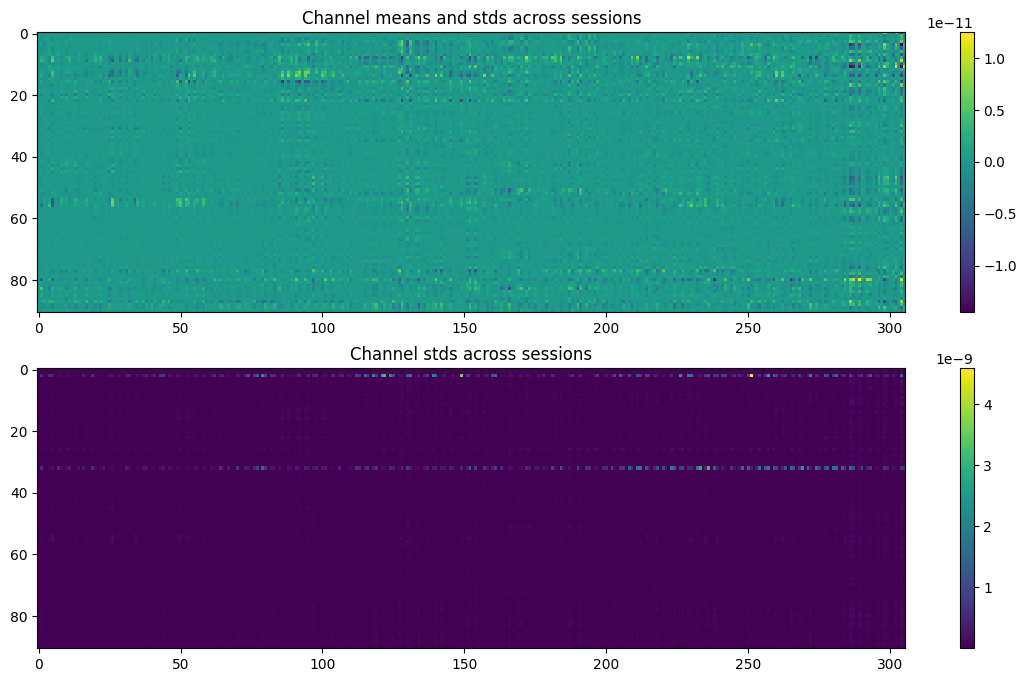

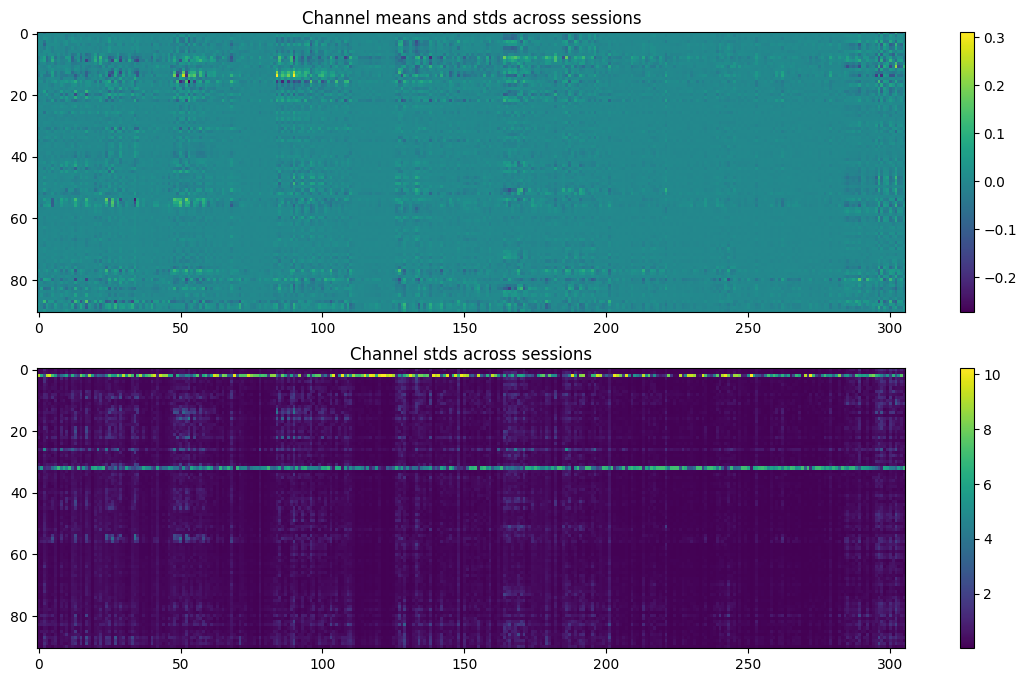

In [27]:
from matplotlib import pyplot as plt

def plot_stats_im(vecs):
    fig, ax = plt.subplots(2, 1, figsize=(14, 8))
    all_vecs = np.stack(list(vecs.values()), axis=0)
    im0 = ax[0].imshow(all_vecs[:, :306], aspect='auto', interpolation='none')
    fig.colorbar(im0, ax=ax[0])
    ax[0].set_title('Channel means and stds across sessions')
    im1 = ax[1].imshow(all_vecs[:, 306:], aspect='auto', interpolation='none')
    fig.colorbar(im1, ax=ax[1])
    ax[1].set_title('Channel stds across sessions')
    plt.show()

plot_stats_im(ds_vecs)
plot_stats_im(ds_vecs_std)

### Cosine Similarity Plot

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
import plotly.graph_objects as go

def plot_similarity_matrix(vecs, using):
    # Compute cosine similarity matrix
    if using == "means":
        vectors = np.array([vecs[key][:306] for key in RUN_KEYS])  # use means only
    elif using == "stds":
        vectors = np.array([vecs[key][306:] for key in RUN_KEYS])  # use stds only
    else:  # using == "stats"
        vectors = np.array([vecs[key] for key in RUN_KEYS])  # use both

    # Normalize vectors, preventing numerical issues
    vectors *= 1.0 / np.linalg.norm(vectors, axis=1, keepdims=True)

    similarity_matrix = cosine_similarity(vectors)

    # Create hover text with run key details
    hover_text = [f"{key[2]}(S{key[1]},R{key[3]})" for key in RUN_KEYS]

    # Identify indices where run == '2'
    highlight_indices = [i for i, key in enumerate(RUN_KEYS) if key[1] == '2025']

    # Create a copy of the similarity matrix for visualization
    fig = go.Figure(data=go.Heatmap(
        z=similarity_matrix,
        x=hover_text,
        y=hover_text,
        colorscale='RdBu',
        zmin=0.5,
        zmax=1,
        hovertemplate='<b>%{y}</b> vs <b>%{x}</b><br>Similarity: %{z:.4f}<extra></extra>'
    ))

    # Add rectangles to highlight rows and columns where key[3] == '2'
    for idx in highlight_indices:
        # Highlight row
        fig.add_shape(type="rect", x0=-0.5, x1=len(RUN_KEYS)-0.5, y0=idx-0.5, y1=idx+0.5,
                    line=dict(color="green", width=2))
        # Highlight column
        fig.add_shape(type="rect", x0=idx-0.5, x1=idx+0.5, y0=-0.5, y1=len(RUN_KEYS)-0.5,
                    line=dict(color="green", width=2))

    fig.update_layout(
        title=f'Cosine Similarity Matrix of Channel {using} Across Runs',
        xaxis_title='Run',
        yaxis_title='Run',
        height=1000,
        width=1000,
    )

    fig.show()

plot_similarity_matrix(ds_vecs, using="means")
plot_similarity_matrix(ds_vecs_std, using="means")

In [ ]:
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import plotly.express as px

# Combine all vectors and create labels
vectors = np.array([ds_vecs[key] for key in RUN_KEYS])
labels = [f"{key[2]}_S{key[1]}_T{key[3]}" for key in RUN_KEYS]

all_tasks = list(set([key[2] for key in RUN_KEYS]))
colors = px.colors.qualitative.Plotly
task2color = {task: colors[i % len(colors)] for i, task in enumerate(all_tasks)}

# Apply t-SNE
tsne = TSNE(n_components=3, random_state=42)
tsne_results = tsne.fit_transform(vectors)

# Create plotly scatter plot
fig = go.Figure(data=go.Scatter3d(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    z=tsne_results[:, 2],
    mode='markers',
    marker=dict(
        size=8,
        color=[task2color[key[2]] for key in RUN_KEYS],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Task")
    ),
    text=labels,
    hoverinfo='text',
))

fig.update_layout(
    title='t-SNE Visualization of Channel Statistics',
    xaxis_title='t-SNE 1',
    yaxis_title='t-SNE 2',
    height=600,
    width=800
)

fig.show()